# Pandas

**What you'll learn:** how to load data, explore it, clean it, and finally find patterns and draw charts.

**Roadmap**
1. Basics: Series, DataFrames, reading CSV/JSON, analyzing data
2. Cleaning data: empty cells, wrong formats, wrong values, duplicates
3. Advanced: correlations and plotting

## 1. Introduction & Getting Started

**Pandas** is the most popular Python library for working with **tabular data** (like Excel sheets or database tables).

**Why use it?**
- Load data from files (CSV, JSON, Excel ...) in one line.
- Filter, sort, group and summarize thousands of rows easily.
- Clean messy real-world data.

Pandas is built on top of NumPy. Install it with `pip install pandas`, then import it. By convention we call it `pd`.

In [1]:
import numpy as np
import pandas as pd

print("Pandas version:", pd.__version__)

df = pd.read_csv("data.csv")
print("Dataset shape:", df.shape)


Pandas version: 2.2.3
Dataset shape: (169, 4)


## 2. Pandas Series

A **Series** is a single column of a DataFrame. Since our dataset contains workout measurements, we can take the `Pulse` column as a real example.

- A Series has values and an index.
- `df["Pulse"]` returns a Series.
- Series methods such as `.mean()`, `.min()`, and `.max()` help us analyze one column.


In [2]:
pulse = df["Pulse"]
print(pulse.head())

print("-" * 30)
print("Pulse at row 0:", pulse.iloc[0])
print("Average pulse:", pulse.mean())
print("Minimum pulse:", pulse.min())
print("Maximum pulse:", pulse.max())


0    110
1    117
2    103
3    109
4    117
Name: Pulse, dtype: int64
------------------------------
Pulse at row 0: 110
Average pulse: 107.46153846153847
Minimum pulse: 80
Maximum pulse: 159


## 3. DataFrames

A **DataFrame** is the complete table: rows and columns. Here, `df` is the actual CSV data.

Common ways to select data:
- `df["col"]` gets one column (a Series).
- `df[["a", "b"]]` gets several columns.
- `df.loc[row_label]` selects by label.
- `df.iloc[row_number]` selects by position.
- `df[df["col"] > value]` filters rows by a condition.


In [12]:
print(df.head())

print("-" * 30)
print(df[["Duration", "Calories"]].head())

print("-" * 30)
print("First row:\n", df.iloc[0])
print(df.loc[df["Duration"] >= 120, ["Duration", "Calories"]])

print("-" * 30)
print("Workouts with Pulse > 120:")
print(df[df["Pulse"] > 120].head())


   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
3        45    109       175     282.4
4        45    117       148     406.0
------------------------------
   Duration  Calories
0        60     409.1
1        60     479.0
2        60     340.0
3        45     282.4
4        45     406.0
------------------------------
First row:
 Duration     60.0
Pulse       110.0
Maxpulse    130.0
Calories    409.1
Name: 0, dtype: float64
     Duration  Calories
60        210    1376.0
61        160    1034.4
62        160     853.0
65        180     800.4
66        150     873.4
67        150     816.0
69        300    1500.2
70        150    1115.0
73        150     953.2
78        120     500.4
79        270    1729.0
83        120     500.0
87        120    1000.1
90        180     600.1
106       180     800.3
109       210    1860.4
------------------------------
Workouts with Pulse > 120

## 4. Reading CSV Files

In a real project, the data usually lives in a file. Our notebook uses the provided CSV throughout the lesson.

- `pd.read_csv("file.csv")` loads a CSV into a DataFrame.
- `df.to_csv("file.csv", index=False)` saves a DataFrame as CSV.

We do **not** create a fake dataset here; all examples below use the provided workout CSV.


In [6]:
# Read the provided CSV
df = pd.read_csv('data.csv')
print(df.head(3))

print("-" * 30)
print("Columns:", df.columns.tolist())
print("Rows and columns:", df.shape)

# Optional: save a copy of the same real data
# df.to_csv("workout_data_copy.csv", index=False)


   Duration  Pulse  Maxpulse  Calories
0        60    110       130     409.1
1        60    117       145     479.0
2        60    103       135     340.0
------------------------------
Columns: ['Duration', 'Pulse', 'Maxpulse', 'Calories']
Rows and columns: (169, 4)


## 5. Analyzing Data

Once the data is loaded, the first thing to do is **look at it**:

| Method | What it tells you |
|---|---|
| `df.head(n)` / `df.tail(n)` | first / last `n` rows |
| `df.shape` | `(rows, columns)` |
| `df.info()` | column names, data types, missing values |
| `df.describe()` | count, mean, min, max ... for numeric columns |
| `df["col"].value_counts()` | how many times each value appears |
| `df.sort_values("col")` | sort the table |
| `df.groupby("col")` | split into groups and calculate per group |

In [7]:
print("Shape:", df.shape)
df.info()


Shape: (169, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  169 non-null    int64  
 1   Pulse     169 non-null    int64  
 2   Maxpulse  169 non-null    int64  
 3   Calories  164 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 5.4 KB


In [8]:
print(df.describe())

print("-" * 30)
print("Duration value counts:")
print(df["Duration"].value_counts().sort_index())

print("-" * 30)
print("Average measurements by Duration:")
print(df.groupby("Duration")[["Pulse", "Maxpulse", "Calories"]].mean().round(2))

print("-" * 30)
print("Top 5 calorie-burning workouts:")
print(df.sort_values("Calories", ascending=False).head(5))


         Duration       Pulse    Maxpulse     Calories
count  169.000000  169.000000  169.000000   164.000000
mean    63.846154  107.461538  134.047337   375.800000
std     42.299949   14.510259   16.450434   266.377134
min     15.000000   80.000000  100.000000    50.300000
25%     45.000000  100.000000  124.000000   250.925000
50%     60.000000  105.000000  131.000000   318.600000
75%     60.000000  111.000000  141.000000   387.600000
max    300.000000  159.000000  184.000000  1860.400000
------------------------------
Duration value counts:
Duration
15      2
20      9
25      1
30     16
45     35
60     79
75      2
80      1
90      8
120     3
150     4
160     2
180     3
210     2
270     1
300     1
Name: count, dtype: int64
------------------------------
Average measurements by Duration:
           Pulse  Maxpulse  Calories
Duration                            
15        102.00    119.50     87.35
20        125.00    146.00    151.60
25        152.00    168.00    244.20
30    

# Cleaning Data

## 6. Why Clean Data?

Real-world data can contain **missing values, wrong formats, wrong values, and duplicates**. Our CSV gives us real examples of some of these problems.

In this dataset:
1. `Calories` contains missing values.
2. The columns are already numeric, so there is no obvious type error to fix; we will still learn how to verify and convert numeric data safely.
3. Two rows have `Pulse >= Maxpulse`, which is suspicious for these measurements and can be treated as invalid values for cleaning practice.
4. There are duplicate rows.

The important point is that the examples below come from the **provided CSV**, not from a randomly generated DataFrame.


In [7]:
# Inspect the actual CSV before cleaning it
print(df.head())
print("-" * 30)
df.info()
print("-" * 30)
print("Missing values:\n", df.isna().sum())
print("Duplicate rows:", df.duplicated().sum())


     Name    Age Salary   Join_Date   Dept
0     Ali   25.0   5000  2023-01-15     IT
1    Sara   30.0   6500  2022-03-20     HR
2    Omar    NaN   7000  2021-07-01     IT
3    Sara   30.0   6500  2022-03-20     HR
4    Mona   28.0   5500  2023-05-10  Sales
5  Khaled  250.0   8000  2020-11-30     IT
6    Nour   35.0   6000  2022-09-05    NaN
------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       7 non-null      str    
 1   Age        6 non-null      float64
 2   Salary     7 non-null      str    
 3   Join_Date  7 non-null      str    
 4   Dept       6 non-null      str    
dtypes: float64(1), str(4)
memory usage: 412.0 bytes


## 7. Clean Empty Cells

Missing values appear as `NaN` (or `None`). You have two choices:

- **Remove** them: `df.dropna()` (removes rows that contain any empty cell).
- **Fill** them: `df.fillna(value)` (replace with a number, the mean/median, or a text like "Unknown").

Use `df.isna().sum()` to count the empty cells in each column.

> Removing rows loses information, so filling is often better when you have little data.

In [8]:
# Work on a copy so the original loaded data remains unchanged
clean_df = df.copy()

print("Missing values before cleaning:")
print(clean_df.isna().sum())

print("Rows left if we drop missing values:", len(clean_df.dropna()), "of", len(clean_df))

# For this dataset, fill missing Calories with the median Calories.
clean_df["Calories"] = clean_df["Calories"].fillna(clean_df["Calories"].median())

print("-" * 30)
print("Missing values after filling Calories:")
print(clean_df.isna().sum())


Name         0
Age          1
Salary       0
Join_Date    0
Dept         1
dtype: int64
Rows left if we drop: 5 of 7
------------------------------
Name         0
Age          0
Salary       0
Join_Date    0
Dept         0
dtype: int64


## 8. Clean Wrong Format

A value can be correct but stored with the wrong data type. First, inspect the actual CSV types with `df.dtypes`.

Our CSV already stores `Duration`, `Pulse`, and `Maxpulse` as integers and `Calories` as a float, so there is no date column or text salary column to repair.

Still, `pd.to_numeric(..., errors="coerce")` is a useful safe conversion when reading real-world CSV files.


In [9]:
print("Types before conversion:")
print(clean_df.dtypes)

# Safe numeric conversion using the actual dataset columns
for col in ["Duration", "Pulse", "Maxpulse", "Calories"]:
    clean_df[col] = pd.to_numeric(clean_df[col], errors="coerce")

print("-" * 30)
print("Types after conversion:")
print(clean_df.dtypes)
print("Average calories:", clean_df["Calories"].mean())


<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Name       7 non-null      str           
 1   Age        7 non-null      int64         
 2   Salary     7 non-null      int64         
 3   Join_Date  7 non-null      datetime64[us]
 4   Dept       7 non-null      str           
dtypes: datetime64[us](1), int64(2), str(2)
memory usage: 412.0 bytes
Average salary: 6357.142857142857
Joined in year: [2023, 2022, 2021, 2022, 2023, 2020, 2022]


## 9. Clean Wrong Data

Some values can have a valid Python type but still be suspicious or invalid according to the meaning of the data.

For this CSV, `Pulse` should not be greater than or equal to `Maxpulse`. We can find those rows with a condition.

Because we do not know the true values that were intended, we should **not invent replacements**. For a cleaning example, we can mark the invalid `Maxpulse` values as missing and then handle them using a documented rule.


In [10]:
invalid_pulse = clean_df["Pulse"] >= clean_df["Maxpulse"]
print("Suspicious rows:")
print(clean_df[invalid_pulse])

# Mark the suspicious Maxpulse values as missing instead of inventing a value.
clean_df.loc[invalid_pulse, "Maxpulse"] = np.nan

# Example documented rule: fill missing Maxpulse with its median.
clean_df["Maxpulse"] = clean_df["Maxpulse"].fillna(clean_df["Maxpulse"].median())

print("-" * 30)
print("Invalid rows remaining:", (clean_df["Pulse"] >= clean_df["Maxpulse"]).sum())


     Name  Age  Salary  Join_Date Dept
5  Khaled  250    8000 2020-11-30   IT
Max age now: 35


## 10. Remove Duplicates

The same row can appear twice (for example if data was entered two times), which makes your counts and averages wrong.

- `df.duplicated()` returns `True` for every repeated row.
- `df.drop_duplicates()` removes them (keeps the first one by default).

In [11]:
print("Duplicated rows before removal:", clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", len(clean_df))
print("Duplicated rows after removal:", clean_df.duplicated().sum())


Duplicated rows: 1
     Name  Age  Salary  Join_Date     Dept
0     Ali   25    5000 2023-01-15       IT
1    Sara   30    6500 2022-03-20       HR
2    Omar   30    7000 2021-07-01       IT
3    Mona   28    5500 2023-05-10    Sales
4  Khaled   30    8000 2020-11-30       IT
5    Nour   35    6000 2022-09-05  Unknown


# Advanced

## 11. Correlations

**Correlation** measures how strongly two numeric columns move together. `df.corr()` gives a value between **-1 and 1**:

- **close to 1**: when one goes up, the other tends to go up
- **close to -1**: when one goes up, the other tends to go down
- **close to 0**: no clear linear relationship

We will calculate correlations using the **actual workout measurements** in the CSV.

>Correlation does **not** prove that one thing causes the other.


In [12]:
print(df[["Duration", "Pulse", "Maxpulse", "Calories"]].corr().round(2))


             Study_Hours  Exam_Score  Phone_Hours
Study_Hours         1.00        0.95        -0.85
Exam_Score          0.95        1.00        -0.80
Phone_Hours        -0.85       -0.80         1.00


## 12. Plotting

Pandas can draw charts directly with `.plot()` (using matplotlib behind the scenes). Choose the chart with `kind=`:

| Chart | When to use |
|---|---|
| `"line"` | change over an ordered sequence |
| `"bar"` | compare categories or grouped values |
| `"hist"` | distribution of one numeric column |
| `"scatter"` | relationship between two numeric columns |

The plots below all use columns from the provided CSV.


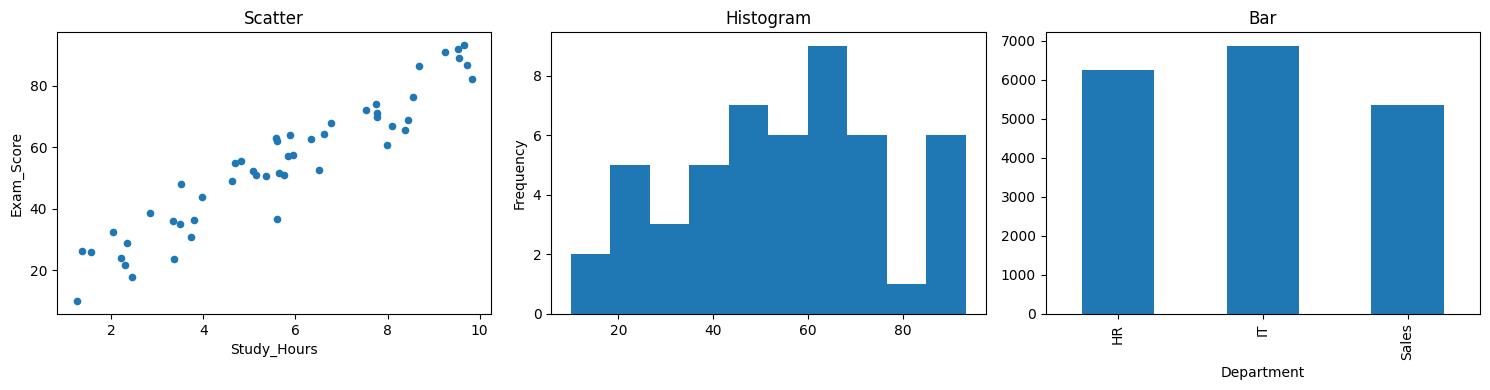

In [13]:
import matplotlib.pyplot as plt

# Scatter: relationship between Duration and Calories
df.plot(kind="scatter", x="Duration", y="Calories", title="Duration vs Calories")
plt.show()

# Histogram: distribution of Calories
df["Calories"].plot(kind="hist", bins=15, title="Calories Distribution")
plt.show()

# Bar: average Calories for each Duration
df.groupby("Duration")["Calories"].mean().sort_index().plot(kind="bar", title="Average Calories by Duration")
plt.xlabel("Duration")
plt.ylabel("Average Calories")
plt.show()


## Summary

| Topic | Remember |
|---|---|
| Structures | `Series` = one column, `DataFrame` = a table |
| Load / Save | `read_csv`, `to_csv` |
| Explore | `head`, `info`, `describe`, `value_counts`, `groupby`, `sort_values` |
| Empty cells | `isna().sum()`, `dropna()`, `fillna()` |
| Wrong format | inspect `dtypes`, use `to_numeric` when needed |
| Wrong data | find with a condition; avoid inventing replacement values |
| Duplicates | `duplicated()`, `drop_duplicates()` |
| Advanced | `corr()` and `.plot(kind=...)` |

## Practice Exercises
1. Read the CSV and calculate the average `Calories` for each `Duration`.
2. Find the workouts whose `Calories` are above the overall average.
3. Add a new column `Calories_per_Minute` equal to `Calories / Duration`, then sort from highest to lowest.
4. Count missing values in every column and fill the missing `Calories` values using the median.
5. Find duplicated rows and remove them.
6. Calculate the correlation between `Duration`, `Pulse`, `Maxpulse`, and `Calories`.
